In [1]:
import sys

project_root = 'c:/big20/git/big20-ML-project2-team3/CreditCardFraud'

# sys.path에 추가 (모듈 import용)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import importlib
from utils import modeling
importlib.reload(modeling)

from matplotlib import rc
rc('font', family='Malgun Gothic')  # Windows 기본 한글 폰트
plt.rcParams['axes.unicode_minus'] = False  # 마이너스(-) 깨짐 방지

import utils.preprocessing as pp 
import utils.data_sampling as ds 
import utils.user_utils    as uu
import utils.modeling      as um

In [3]:
# data loading
df = pp.ccf_load_data()

데이터 로드 성공: (284807, 31)


In [4]:
# 전처리

# 1. 이상치 개수 계산 함수
def count_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return ((series < lower_bound) | (series > upper_bound)).sum()

# 2. 피처별 이상치 개수 확인
outlier_counts = {}
for col in df.columns:
    if df[col].dtype != 'object':  # 수치형만
        outlier_counts[col] = count_outliers(df[col])

# 3. 이상치가 10,000건 이상인 피처 추출
selected_features = [col for col, cnt in outlier_counts.items() if cnt >= 10000]
print("이상치가 많은 피처들:", selected_features)

# 4. 해당 피처들의 이상치 행 삭제
mask = pd.Series([False] * len(df))
for col in selected_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    mask |= (df[col] < lower_bound) | (df[col] > upper_bound)

df_cleaned = df[~mask]
print("삭제 후 데이터 크기:", df_cleaned.shape)

이상치가 많은 피처들: ['V2', 'V4', 'V5', 'V6', 'V8', 'V12', 'V14', 'V19', 'V20', 'V21', 'V23', 'V27', 'V28', 'Amount']
삭제 후 데이터 크기: (162440, 31)


In [5]:
# 삭제된 행만 추출
df_outliers = df[mask]

print("삭제된 행 개수:", df_outliers.shape)
df_outliers.head()

삭제된 행 개수: (122367, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
11,10.0,0.384978,0.616109,-0.874300,-0.094019,2.924584,3.317027,0.470455,0.538247,-0.558895,...,0.049924,0.238422,0.009130,0.996710,-0.767315,-0.492208,0.042472,-0.054337,9.99,0
14,12.0,-2.791855,-0.327771,1.641750,1.767473,-0.136588,0.807596,-0.422911,-1.907107,0.755713,...,1.151663,0.222182,1.020586,0.028317,-0.232746,-0.235557,-0.164778,-0.030154,58.80,0


In [ ]:
# selected_features 리스트를 활용

outlier_indices = {}
for col in selected_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outlier_indices[col] = df[(df[col] < lower_bound) | (df[col] > upper_bound)].index

# 예시: 첫 번째 피처의 이상치 인덱스 확인
first_feature = selected_features[0]
print(f"{first_feature} 이상치 행 인덱스:", outlier_indices[first_feature][:10])

V2 이상치 행 인덱스: Index([18, 85, 89, 146, 164, 174, 210, 225, 235, 249], dtype='int64')


In [9]:
df_outliers = df.loc[mask]   # mask == True인 행들
print("삭제된 행 개수:", df_outliers.shape)
df_outliers.head()

삭제된 행 개수: (122367, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
11,10.0,0.384978,0.616109,-0.874300,-0.094019,2.924584,3.317027,0.470455,0.538247,-0.558895,...,0.049924,0.238422,0.009130,0.996710,-0.767315,-0.492208,0.042472,-0.054337,9.99,0
14,12.0,-2.791855,-0.327771,1.641750,1.767473,-0.136588,0.807596,-0.422911,-1.907107,0.755713,...,1.151663,0.222182,1.020586,0.028317,-0.232746,-0.235557,-0.164778,-0.030154,58.80,0


In [ ]:
# Amount 컬럼만 log1p 적용 (scaled 적용 X)
df['Amount'] = np.log1p(df['Amount'])

# 이후 전처리 과정에서 StandardScaler는 생략


# 특성과 타겟 분리 (Time 컬럼 제거)
X_features, y_target = pp.split_features_target(df, cols='Time')

# 학습/테스트 분할
X_train, X_test, y_train, y_test = pp.data_split(X_features, y_target)

print("Amount 컬럼 변환 후 예시:")
print(df['Amount'].head())

Amount 컬럼 변환 후 예시:
0    5.014760
1    1.305626
2    5.939276
3    4.824306
4    4.262539
Name: Amount, dtype: float64


In [11]:
# 각 모델 적용

# baseline 성능 확인
lr_best_params = {
    "random_state": 23,
    'C': 0.029,
    'max_iter': 1000,
    'penalty': 'l2',
    'solver': 'lbfgs',
    'class_weight': 'balanced',
    "n_jobs": -1
}

# GradientBoostingClassifier 기본 파라미터
gb_basic_params = {
    'n_estimators': 100,      # 트리 개수 (더 많을수록 성능↑, 시간↑)
    'learning_rate': 0.1,     # 학습률 (0.01~0.3, 작을수록 안정적)
    'max_depth': 3,           # 개별 트리 깊이 (3~5 권장, 과적합 방지)
    'random_state': 23
}

# DecisionTreeClassifier 기본 파라미터
dt_basic_params = {
    'criterion': 'gini',      # 분할 기준 ('gini' 또는 'entropy')
    'max_depth': None,        # 트리 최대 깊이 (None=제한없음, 과적합 위험)
    'random_state': 23
}

# MLPClassifier 기본 파라미터
mlp_basic_params = {
    'hidden_layer_sizes': (64, 32),  # 은닉층 구조 (64개 노드 → 32개 노드)
    'activation': 'relu',             # 활성화 함수 (relu, tanh, logistic)
    'solver': 'adam',                 # 최적화 알고리즘 (adam, sgd, lbfgs)
    'alpha': 1e-4,                    # L2 정규화 파라미터 (과적합 방지)
    'batch_size': 256,                # 배치 크기 (메모리 허용 범위 내 크게)
    'learning_rate': 'adaptive',      # 학습률 스케줄 (adaptive, constant, invscaling)
    'max_iter': 50,                   # 최대 반복 횟수 (early stopping 권장)
    'random_state': 23
}

# LightGBM 기본 파라미터
lgb_basic_params = {
    'random_state': 23,
    'n_estimators': 400,       # 트리 개수 (기본 100, 많을수록 성능↑, 시간↑)
    'num_leaves': 36,          # 리프 노드 개수 (기본 31, 복잡도 조절)
    'learning_rate': 0.03,     # 학습률 (0.01~0.3 권장)
    'subsample': 0.9, 
    'colsample_bytree': 0.75,       # 부스팅 방식 (gbdt, dart, goss)
    'reg_alpha' : 0.6,
    'reg_lambda' : 0.2,
    'class_weight': {0:1, 1:10},    # 불균형 데이터 처리
    'n_jobs': -1                    # 병렬 처리
}

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from lightgbm import LGBMClassifier

# 딕셔너리 저장소 생성

results_dict = {}


# 1. Logistic Regression
model_name = 'LogReg_DelOutlier_AmountLog1p_Timedrop__2025_11_27'
lr_clf = LogisticRegression(**lr_best_params)
results_dict['origin'] = uu.get_model_train_eval(lr_clf, model_name, X_train, X_test, y_train, y_test)

# 2. Gradient Boosting
model_name = 'GradientBoosting_DelOutlier_AmountLog1p_Timedrop__2025_11_27'
gb_clf = GradientBoostingClassifier(**gb_basic_params)
results_dict['gb'] = uu.get_model_train_eval(gb_clf, model_name, X_train, X_test, y_train, y_test)

# 3. Decision Tree
model_name = 'DecisionTree_DelOutlier_AmountLog1p_Timedrop__2025_11_27'
dt_clf = DecisionTreeClassifier(**dt_basic_params)
results_dict['dt'] = uu.get_model_train_eval(dt_clf, model_name, X_train, X_test, y_train, y_test)

# 4. MLP (Multi-Layer Perceptron)
model_name = 'MLP_DelOutlier_AmountLog1p_Timedrop__2025_11_27'
mlp_clf = MLPClassifier(**mlp_basic_params)
results_dict['mlp'] = uu.get_model_train_eval(mlp_clf, model_name, X_train, X_test, y_train, y_test)

# 5. LightGBM
model_name = 'LightGBM_DelOutlier_AmountLog1p_Timedrop__2025_11_27'
lgb_clf = LGBMClassifier(**lgb_basic_params)
results_dict['lgbm'] = uu.get_model_train_eval(lgb_clf, model_name, X_train, X_test, y_train, y_test)

result = '''
✓ 모델 저장 완료: ../models\LogReg_DelOutlier_AmountLog1p_Timedrop__2025_11_27.pkl
  파일 크기: 0.00 MB
folder = c:\big20\git\big20-ML-project2-team3\CreditCardFraud\results
AUC: 0.9588, 정확도: 0.9754, 정밀도: 0.0582, 재현율: 0.8776, F1: 0.1092
오차행렬:
[[55473  1391]
 [   12    86]]
실행 시간: 3.9511349201202393
✓ 모델 저장 완료: ../models\GradientBoosting_DelOutlier_AmountLog1p_Timedrop__2025_11_27.pkl
  파일 크기: 0.13 MB
folder = c:\big20\git\big20-ML-project2-team3\CreditCardFraud\results
AUC: 0.2959, 정확도: 0.9985, 정밀도: 0.7308, 재현율: 0.1939, F1: 0.3065
오차행렬:
[[56857     7]
 [   79    19]]
실행 시간: 297.2983419895172
✓ 모델 저장 완료: ../models\DecisionTree_DelOutlier_AmountLog1p_Timedrop__2025_11_27.pkl
  파일 크기: 0.03 MB
folder = c:\big20\git\big20-ML-project2-team3\CreditCardFraud\results
AUC: 0.8927, 정확도: 0.9993, 정밀도: 0.7857, 재현율: 0.7857, F1: 0.7857
오차행렬:
[[56843    21]
 [   21    77]]
실행 시간: 20.134258270263672
✓ 모델 저장 완료: ../models\MLP_DelOutlier_AmountLog1p_Timedrop__2025_11_27.pkl
  파일 크기: 0.13 MB
folder = c:\big20\git\big20-ML-project2-team3\CreditCardFraud\results
AUC: 0.9639, 정확도: 0.9996, 정밀도: 0.9213, 재현율: 0.8367, F1: 0.8770
오차행렬:
[[56857     7]
 [   16    82]]
실행 시간: 24.111942291259766
✓ 모델 저장 완료: ../models\LightGBM_DelOutlier_AmountLog1p_Timedrop__2025_11_27.pkl
  파일 크기: 1.47 MB
folder = c:\big20\git\big20-ML-project2-team3\CreditCardFraud\results
AUC: 0.9681, 정확도: 0.9997, 정밀도: 0.9647, 재현율: 0.8367, F1: 0.8962
오차행렬:
[[56861     3]
 [   16    82]]
실행 시간: 3.2129979133605957
'''

✓ 모델 저장 완료: ../models\LogReg_DelOutlier_AmountLog1p_Timedrop__2025_11_27.pkl
  파일 크기: 0.00 MB
folder = c:\big20\git\big20-ML-project2-team3\CreditCardFraud\results
AUC: 0.9588, 정확도: 0.9754, 정밀도: 0.0582, 재현율: 0.8776, F1: 0.1092
오차행렬:
[[55473  1391]
 [   12    86]]
실행 시간: 3.9511349201202393
✓ 모델 저장 완료: ../models\GradientBoosting_DelOutlier_AmountLog1p_Timedrop__2025_11_27.pkl
  파일 크기: 0.13 MB
folder = c:\big20\git\big20-ML-project2-team3\CreditCardFraud\results
AUC: 0.2959, 정확도: 0.9985, 정밀도: 0.7308, 재현율: 0.1939, F1: 0.3065
오차행렬:
[[56857     7]
 [   79    19]]
실행 시간: 297.2983419895172
✓ 모델 저장 완료: ../models\DecisionTree_DelOutlier_AmountLog1p_Timedrop__2025_11_27.pkl
  파일 크기: 0.03 MB
folder = c:\big20\git\big20-ML-project2-team3\CreditCardFraud\results
AUC: 0.8927, 정확도: 0.9993, 정밀도: 0.7857, 재현율: 0.7857, F1: 0.7857
오차행렬:
[[56843    21]
 [   21    77]]
실행 시간: 20.134258270263672
✓ 모델 저장 완료: ../models\MLP_DelOutlier_AmountLog1p_Timedrop__2025_11_27.pkl
  파일 크기: 0.13 MB
folder = c:\big20\git\bi

In [13]:
results_dict

{'origin': {'AUC': 0.9588, '정밀도': 0.0582, '재현율': 0.8776, 'F1': 0.1092},
 'gb': {'AUC': 0.2959, '정밀도': 0.7308, '재현율': 0.1939, 'F1': 0.3065},
 'dt': {'AUC': 0.8927, '정밀도': 0.7857, '재현율': 0.7857, 'F1': 0.7857},
 'mlp': {'AUC': 0.9639, '정밀도': 0.9213, '재현율': 0.8367, 'F1': 0.877},
 'lgbm': {'AUC': 0.9681, '정밀도': 0.9647, '재현율': 0.8367, 'F1': 0.8962}}

📁 그래프 저장 완료: ..\images\Delete Outlier_Amount_log1p 모델별 평가 지표_2025_1127.png


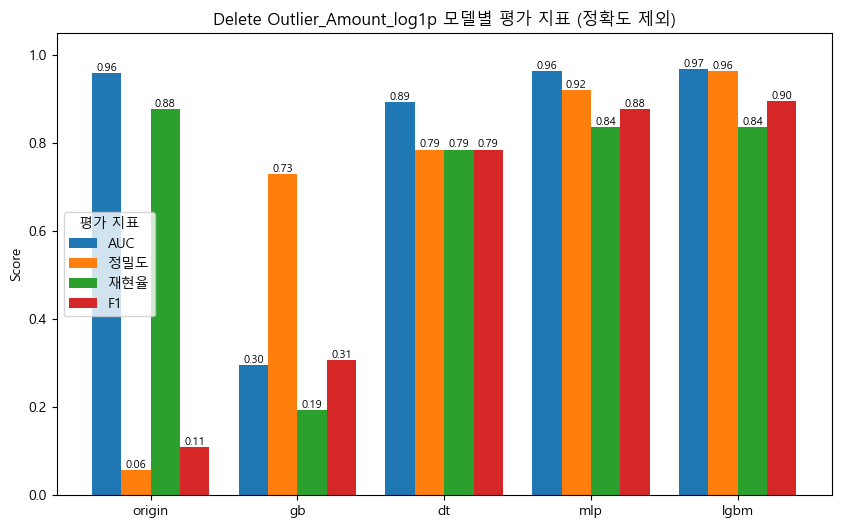

In [16]:
um.plot_sampling_metrics(results_dict,title='Delete Outlier_Amount_log1p 모델별 평가 지표')